# DEMF – ML Pipeline (Simplified)

This notebook runs the complete **Data Exfiltration Monitoring Framework (DEMF)** prototype on **CERT-style logs**:

- `logon.csv` (logon/logoff)
- `device.csv` (USB connect/disconnect)
- `http.csv` (URL visits)

It builds **user-day features**, trains **unsupervised models**:

- Autoencoder-like reconstruction (**MLPRegressor trained to reconstruct the input**)
- One-Class SVM

Then it produces:

- `reports/current/alerts.csv`
- `reports/current/features.csv`
- `reports/current/events_standardized.csv`

> Tip: A small **sample dataset** is included at `data/sample_raw/` so you can run end-to-end immediately.


In [1]:
from pathlib import Path
import pandas as pd

# Core DEMF functions live in ONE file:
from demf_core import DEMFConfig, run_train_and_detect, run_detect_only

ROOT = Path().resolve()
ROOT


WindowsPath('C:/Users/piyum/PycharmProjects/PythonProject11')

## 1) Load config

Edit `config.yaml` if you want to change folders / weights / business hours / canary tokens.


In [2]:
cfg = DEMFConfig.from_yaml(Path("config.yaml"))

# ✅ QUICK START (sample data):
# cfg.raw_dir = Path("data/sample_raw")
# cfg.model_dir = Path("models/sample")
# cfg.report_dir = Path("reports/sample")

cfg


DEMFConfig(raw_dir=WindowsPath('data/raw'), model_dir=WindowsPath('models/current'), report_dir=WindowsPath('reports/current'), labels_path=None, hash_salt='demo_salt_change_me', bh_start=8, bh_end=18, contamination=0.01, ae_weight=0.6, svm_weight=0.4, context_weight=0.2, canary_tokens=('DEMF_CANARY_TOKEN', 'canary.example.com'), random_state=42, max_iter=300)

## 2) Train + Detect (recommended first run)

This will:
1. Load logs from `cfg.raw_dir`
2. Hash users (SHA-256)
3. Build user-day features
4. Train models
5. Score and create alerts
6. Save outputs under `cfg.model_dir` and `cfg.report_dir`


In [26]:
out = run_train_and_detect(cfg)

events = out["events"]
features = out["features"]
scores = out["scores"]

events.head(), features.head(), scores.head()


(                   event_id           timestamp          user       pc source  \
 0  {Y6O4-A7KC67IN-0899AOZK} 2010-01-04 00:10:37  DTAA/KEE0997  PC-1914  logon   
 1  {O5Y6-O7CJ02JC-6704RWBS} 2010-01-04 00:52:16  DTAA/KEE0997  PC-1914  logon   
 2  {D2D1-C6EB14QJ-2100RSZO} 2010-01-04 01:17:20  DTAA/KEE0997  PC-3363  logon   
 3  {H9W1-X0MC70BT-6065RPAT} 2010-01-04 01:28:34  DTAA/KEE0997  PC-3363  logon   
 4  {H3H4-S5AZ00AZ-9560IYHC} 2010-01-04 01:57:30  DTAA/BJM0992  PC-3058  logon   
 
    action   url                       event_uid  \
 0   logon  <NA>  logon:{Y6O4-A7KC67IN-0899AOZK}   
 1  logoff  <NA>  logon:{O5Y6-O7CJ02JC-6704RWBS}   
 2   logon  <NA>  logon:{D2D1-C6EB14QJ-2100RSZO}   
 3  logoff  <NA>  logon:{H9W1-X0MC70BT-6065RPAT}   
 4   logon  <NA>  logon:{H3H4-S5AZ00AZ-9560IYHC}   
 
                                            user_hash  
 0  307c8cb38c1d1be62feab114e99be24ef0bd427bda9cf2...  
 1  307c8cb38c1d1be62feab114e99be24ef0bd427bda9cf2...  
 2  307c8cb38c1d1be62fea

## 3) Quick evaluation / sanity checks

## 3A) Ground-truth evaluation (optional)

If you have a labels (ground-truth) CSV, DEMF can compute **F1, precision, recall, accuracy**, plus a **threshold sweep** and **daily metrics**.

Set the labels path in either:
- `config.yaml` → `evaluation.labels_path`, or
- directly in the notebook: `cfg.labels_path = Path("...")`


Evaluation summary:


,status,labels_path,labeled_rows,positive_labels,positive_rate,precision,recall,f1,accuracy,roc_auc,pr_auc,current_threshold,best_threshold,best_f1,tn,fp,fn,tp
0,ok,data\labels.csv,334905,6698,0.02,0.079984,0.091818,0.085494,0.960714,0.462837,0.030979,0.207167,0.18,0.089311,321133,7074,6083,615


Confusion matrix [[TN, FP],[FN, TP]]:


,Pred 0,Pred 1
Actual 0,321133,7074
Actual 1,6083,615


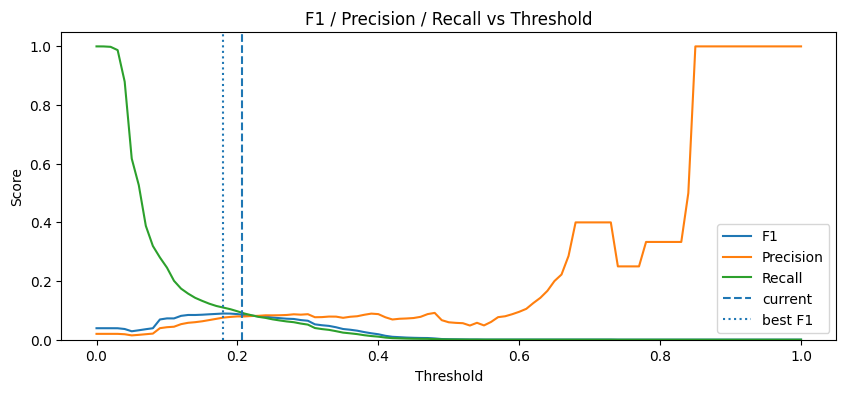

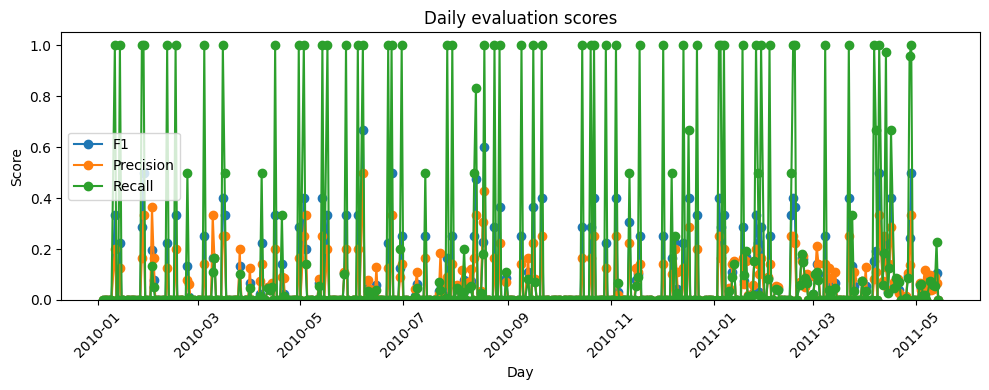


Saved evaluation artifacts into: reports\current


In [28]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from demf_core import save_evaluation_reports

# Optionally override here (otherwise uses config.yaml -> evaluation.labels_path)
cfg.labels_path = Path('data/labels.csv')

if cfg.labels_path is None or not Path(cfg.labels_path).exists():
    print('No labels file configured. Set cfg.labels_path or config.yaml -> evaluation.labels_path to compute F1.')
else:
    eval_out = save_evaluation_reports(scores=scores, features=features, cfg=cfg)
    summary = eval_out['summary']
    print('Evaluation summary:')
    display(pd.DataFrame([summary]))

    # Confusion matrix
    cm = np.array([[summary.get('tn', 0), summary.get('fp', 0)],
                   [summary.get('fn', 0), summary.get('tp', 0)]])
    print('Confusion matrix [[TN, FP],[FN, TP]]:')
    display(pd.DataFrame(cm, index=['Actual 0','Actual 1'], columns=['Pred 0','Pred 1']))

    # Threshold sweep plot
    curve = eval_out['curve']
    plt.figure(figsize=(10,4))
    plt.plot(curve['threshold'], curve['f1'], label='F1')
    plt.plot(curve['threshold'], curve['precision'], label='Precision')
    plt.plot(curve['threshold'], curve['recall'], label='Recall')
    if summary.get('current_threshold') is not None:
        plt.axvline(summary['current_threshold'], linestyle='--', label='current')
    if summary.get('best_threshold') is not None:
        plt.axvline(summary['best_threshold'], linestyle=':', label='best F1')
    plt.ylim(0,1.05)
    plt.title('F1 / Precision / Recall vs Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.show()

    # Daily metrics plot (if multiple days)
    per_day = eval_out['per_day']
    if not per_day.empty:
        per_day = per_day.sort_values('day')
        plt.figure(figsize=(10,4))
        plt.plot(per_day['day'], per_day['f1'], marker='o', label='F1')
        plt.plot(per_day['day'], per_day['precision'], marker='o', label='Precision')
        plt.plot(per_day['day'], per_day['recall'], marker='o', label='Recall')
        plt.ylim(0,1.05)
        plt.title('Daily evaluation scores')
        plt.xlabel('Day')
        plt.ylabel('Score')
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    print('\nSaved evaluation artifacts into:', cfg.report_dir)


In [29]:
# KPIs
total_user_days = len(scores)
total_alerts = int(scores["alert"].sum())
critical = int((scores["severity"] == "critical").sum()) if "severity" in scores.columns else 0
high = int((scores["severity"] == "high").sum()) if "severity" in scores.columns else 0

total_user_days, total_alerts, critical, high


(334905, 7689, 0, 1)

In [30]:
# Top alerts
scores.sort_values("final_score", ascending=False).head(20)


,user_hash,day,recon_error,svm_anom,combined_score,final_score,threshold,alert,severity,top_factors,explanation
282555,9f784c19941d873bbea3ddebcc114ac16cbf3ac32480d6...,2011-02-24,470.760988,95.457316,1.000000,1.000000,0.207167,True,high,"after_hours_url_count, after_hours_usb_connect...",After-hours USB usage | After-hours logon | Af...
149584,571b370d5cf5ac0fb7242c72552f62df14db502ab7184c...,2010-08-06,336.775607,94.457316,0.826418,0.848868,0.207167,True,low,"after_hours_url_count, after_hours_usb_connect...",After-hours USB usage | After-hours logon | Af...
334652,bad0b32c69cef4ded8e9446e4d4d562a9f080ab17a567e...,2011-05-13,323.521007,95.457316,0.812279,0.836558,0.207167,True,low,"after_hours_url_count, after_hours_usb_connect...",After-hours USB usage | After-hours logon | Af...
323383,be15b0c949161a37cb113edb95f03389d7299de2c23cb5...,2011-04-27,369.389438,95.457316,0.870758,0.778641,0.207167,True,low,"after_hours_url_count, logon_count, url_count",After-hours logon | After-hours web activity |...
149442,3055e5b53dee8d14b1798da5ee4b4491552167196c74c5...,2010-08-06,237.066086,94.456956,0.699294,0.738186,0.207167,True,low,"after_hours_url_count, after_hours_usb_connect...",After-hours USB usage | After-hours logon | Af...
323573,ef95c28c1aa9f75975497c07c177be078ed234f8f87fda...,2011-04-27,272.628573,95.457316,0.747395,0.671233,0.207167,True,low,"after_hours_url_count, logon_count, url_count",After-hours logon | After-hours web activity |...
323581,f2f4767a59994d5a901898a93c96fab78ece5edc49020f...,2011-04-27,272.088832,95.457316,0.746706,0.670634,0.207167,True,low,"after_hours_url_count, logon_count, url_count",After-hours logon | After-hours web activity |...
281862,df6087775426e678632abca258cd8fb10cecf9a9908c00...,2011-02-23,238.989475,95.455756,0.704503,0.666538,0.207167,True,low,"after_hours_url_count, logon_count, unique_pcs",After-hours logon | After-hours web activity |...
281551,917554d01d83de02e6170840fad756285f4bb71255200c...,2011-02-23,208.773081,95.418681,0.665876,0.665558,0.207167,True,low,"after_hours_url_count, after_hours_usb_connect...",After-hours USB usage | After-hours web activi...
155507,6da03397214bf20c246298c889f2ba593f4541a5f0d328...,2010-08-16,201.628986,94.456872,0.654114,0.655316,0.207167,True,low,"after_hours_url_count, after_hours_usb_connect...",After-hours USB usage | After-hours web activi...


## 4) Inspect a single user

In [31]:
user = scores.sort_values("final_score", ascending=False).iloc[0]["user_hash"]
user


'9f784c19941d873bbea3ddebcc114ac16cbf3ac32480d6110ee68bfbb6373c7e'

In [32]:
u_scores = scores[scores["user_hash"] == user].sort_values("day")
u_feats = features[features["user_hash"] == user].sort_values("day")

u_scores.tail(10), u_feats.tail(10)


(                                                user_hash        day  \
 326089  9f784c19941d873bbea3ddebcc114ac16cbf3ac32480d6... 2011-05-02   
 327028  9f784c19941d873bbea3ddebcc114ac16cbf3ac32480d6... 2011-05-03   
 327967  9f784c19941d873bbea3ddebcc114ac16cbf3ac32480d6... 2011-05-04   
 328906  9f784c19941d873bbea3ddebcc114ac16cbf3ac32480d6... 2011-05-05   
 329844  9f784c19941d873bbea3ddebcc114ac16cbf3ac32480d6... 2011-05-06   
 330793  9f784c19941d873bbea3ddebcc114ac16cbf3ac32480d6... 2011-05-09   
 331730  9f784c19941d873bbea3ddebcc114ac16cbf3ac32480d6... 2011-05-10   
 332667  9f784c19941d873bbea3ddebcc114ac16cbf3ac32480d6... 2011-05-11   
 333604  9f784c19941d873bbea3ddebcc114ac16cbf3ac32480d6... 2011-05-12   
 334541  9f784c19941d873bbea3ddebcc114ac16cbf3ac32480d6... 2011-05-13   
 
         recon_error   svm_anom  combined_score  final_score  threshold  alert  \
 326089     0.049354 -10.986089        0.106121     0.112899   0.207167  False   
 327028     0.095365 -22.480778

## 5) Detect-only mode

Use this when you already trained models and only want new scoring.


In [33]:
# Example:
# out2 = run_detect_only(cfg)
# out2["scores"].head()


## 6) Where outputs are saved

- Alerts: `reports/.../alerts.csv`
- Features: `reports/.../features.csv`
- Standardized events: `reports/.../events_standardized.csv`
- Models: `models/.../` (scaler, autoencoder, ocsvm, threshold, feature list)
